<a href="https://colab.research.google.com/github/Gr1lledChee5e/TimeSeriesForcastingPortfolio/blob/main/Sales-demand-forecasting-hierarchy-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Executive Summary

This analysis evaluates monthly sales across a three-level product hierarchy (Category1 / Category2 / Category3) from December 2010 through August 2016. The objective was to (1) explore structural characteristics of the data and (2) generate 12-month forecasts for the most commercially important product categories.

Major findings emerged:
- Structural Regime Shift (Figure 1: Total Monthly Sales)
- Total sales exhibit a pronounced level shift beginning in January 2013.
- Pre-2013 average monthly sales: ~$4M
- Post-2013 average monthly sales: ~$126M
- Approximate increase: ~2,800%

The magnitude and abruptness of this change strongly suggest a reporting inclusion change, product portfolio expansion, or channel rollout rather than organic growth. This structural break should be validated with stakeholders prior to operational forecasting.

Stable Annual Seasonality (Figure 2: Month-of-Year Profile)
Month-of-year averages demonstrate consistent seasonal behavior:
- Q4 average sales ≈ 15% higher than non-Q4 months
- December consistently represents the peak month
- Seasonal index difference between trough (October) and peak (December) approaches 2x

This repeated pattern across years justifies the use of seasonal time-series models (season_length = 12).

Revenue Concentration
Sales are highly concentrated in a small subset of product combinations. To maximize business relevance, forecasts were generated for the top two revenue-driving series within each Category1 group based on trailing 12-month sales (six total series).

Rolling cross-validation indicates that AutoARIMA slightly outperforms ETS (Holt-Winters) in most high-volume series, though differences are modest. Forecasts project continued seasonal patterns with no evidence of further regime shifts.


##Data Preparation

The dataset was provided in wide format with monthly columns labeled “YY-MMM” (e.g., 10-Dec, 11-Jan). To ensure compatibility with forecasting frameworks, the data was transformed into tidy time-series format (unique_id, ds, y).

Key preparation steps included:

- Removal of blank category rows
- Imputation of missing Category3 values as “ALL”
- Wide-to-long reshaping
- Parsing month strings to datetime
- Numeric coercion of sales values
- Clipping negative sales to zero (likely return/adjustment artifacts)
- aggregation of duplicate category/date combinations
- standardization to month-start frequency

The resulting dataset contains 78 unique time series spanning December 2010 to August 2016.


##Exploratory Data Analysis
###Structural Break

Figure 1: Total Monthly Sales (All Categories) clearly shows minimal activity from 2010–2012 followed by a dramatic level increase beginning in 2013.

The ~28x increase in average monthly sales suggests a structural data change rather than economic growth. Importantly:
1. The shift is abrupt rather than gradual.
2. The variance post-2013 scales proportionally with the new level.

Seasonal amplitude increases with level.

If the pre-2013 data represents incomplete coverage, modeling should be restricted to post-2013 observations for operational forecasting.

###Seasonality

Figure 2: Average Sales by Month-of-Year shows consistent seasonality:
- Q4 uplift ≈ +15% relative to non-Q4 months
- December peak recurring annually
- Stable month-to-month ranking across years
- While the magnitude of seasonal uplift is moderate, its consistency across multiple years strengthens model reliability.


###Category Selection Strategy

To address the prompt’s open-ended instruction (“some of the most important product categories”), the following objective selection rule was applied:

Select the top 2 revenue-generating series per Category1 group based on last 12 months of observed sales.

This ensures:
- Coverage across major product groups
- Focus on highest commercial impact categories
- Avoidance of low-volume, high-noise series
- Six series were selected for forecasting.

##Forecasting Methodology
### Validation Approach

Forecast accuracy was evaluated using:
- Expanding-window rolling cross-validation
- 1-step-ahead predictions
- Final 12 months held as test set
- Evaluation metric: sMAPE
- This approach mirrors production forecasting conditions and avoids information leakage.


### Models Evaluated

Two models were compared:

Model A: AutoARIMA (StatsForecast)
- Automatic order selection
- Seasonal differencing (period = 12)
- Captures autoregressive structure

Model B: Holt-Winters ETS
- Additive trend
- Additive seasonality (period = 12)
- Strong baseline model for retail demand

Across selected series:
- AutoARIMA marginally outperformed ETS in most cases.
- sMAPE differences were generally small, indicating both models capture primary signal structure.
- No series exhibited explosive trend beyond seasonal fluctuation.


##Forecast Results

Figures 3–8: History + 12-Month Forecast by Selected Series show:
- Continued seasonal peaks in Q4
- Stable year-over-year level
- No evidence of accelerating growth
- Forecast intervals (ETS) widening moderately over horizon

Forecast horizon: September 2016 – August 2017.

All forecasts were exported in CSV format with the following fields:
- Category1
- Category2
- Category3
- unique_id
- ds
- yhat
- yhat_lower80
- yhat_upper80
- model

##Risks and Considerations

Primary considerations:
1. Structural break in 2013 may bias long-term level estimation.
2. No exogenous regressors (promotions, macroeconomic drivers, pricing) included.
3. Forecasts are generated at leaf level; hierarchical reconciliation was not performed.
4. Forecast intervals for AutoARIMA were not explicitly derived.

For operational deployment, I would:
1. Validate 2013 regime shift with business stakeholders.
2. Consider restricting training data to post-2013.
3. Evaluate hierarchical reconciliation (bottom-up or MinT).
4. Explore ensemble methods for marginal accuracy improvement.


# Therefore ...

This analysis sought to understand historical sales performance in a multi-level product hierarchy and generate forecasts for the most relevant product groups in a forward-looking capacity. This type of analysis not only requires a statistical model but also a thorough understanding of interpreting structural patterns within the data.

Two structural elements are evident within the dataset. First, the total sales exhibit a sharp and instantaneous level shift in early 2013. The magnitude of this change, representing a 28-fold increase in average monthly sales, points towards a change in the reporting scope or product portfolio rather than a change in demand patterns. This has important implications for the model. Forecasting accuracy will depend on whether the data points prior to 2013 are representative of the same process as those after 2013. If not, using these points for training could lead to a bias in level estimation.

Second, the dataset shows a consistent year-over-year annual seasonality in sales patterns, with a consistent increase in demand in Q4 relative to the rest of the year, with a peak in demand in the month of December, representing a 15% increase in demand compared to non-Q4 periods. This consistent year-over-year seasonality in sales patterns gives confidence in using a seasonal time series model and points towards a continued increase in sales in the year-end period.

The comparison of the two models using the "rolling expanding window cross-validation" approach indicated that the AutoARIMA and the Holt-Winters ETS model both successfully captured the underlying signal structure, with AutoARIMA achieving a small accuracy advantage in most high-volume series. This relatively small difference in accuracy between the two models suggests that the underlying data is well explained using classical seasonal modeling techniques. It also implies that forecast stability is likely more important than achieving small metric-based improvements.

The generated forecasts in this analysis indicate a continued pattern of seasonality, with stable levels in the data from 2013 onwards. There are no underlying indicators to suggest any acceleration, deceleration, or regime shifts within the forecast horizon.

The present analysis demonstrates the importance of robust data preprocessing, structural analysis, and validation-based model selection. Prior to the deployment of the model, the regime shift in the data in 2013 should be verified with business stakeholders. In addition, the use of hierarchical reconciliation should be considered in the case of aggregated forecast consumption. With these considerations in place, the generated forecasts are robust and analytically sound.


The analysis reveals three primary insights. First, the dataset exhibits a significant structural regime shift beginning in early 2013, with average monthly sales increasing approximately 28-fold (from roughly $4M to $126M), strongly suggesting a reporting, channel, or portfolio inclusion change rather than organic growth; validating this shift is critical for forecast reliability. Second, sales demonstrate consistent and repeatable annual seasonality, with Q4 demand approximately 15% higher than non-Q4 months and December serving as the recurring peak, supporting the use of seasonal time-series models. Third, revenue is highly concentrated among a small subset of product categories, justifying the focus on the top revenue-driving series per Category1 group. Rolling cross-validation shows that AutoARIMA marginally outperforms Holt-Winters ETS, though both models capture the dominant demand structure effectively. The resulting 12-month forecasts project stable continuation of post-2013 levels and established seasonal patterns, with the primary analytical risk remaining confirmation of the 2013 structural break.

From the analysis, three specific conclusions are evident, each with hard numbers to support them. First, a notable structural shift is evident from January 2013 onwards, with average monthly sales rising from a mere $4 million prior to 2013 to a whopping $126 million after 2013, a rise of 2,800%. This indicates a change in reporting, channels, or portfolio size rather than real sales growth. Second, sales exhibit a regular yearly pattern. Quarterly sales in Q4 are 15% higher than those in other months, with December consistently recording the highest sales, with a gap in seasonal indices almost twice as wide from the lowest to the highest sales months. Third, sales are highly concentrated, with a small number of combinations generating a large percentage of total sales, thus justifying a focus on the top two revenue-generating series per Category1 group based on trailing 12-month performance.

To validate these findings, a series of rolling expanding window tests were run on the most recent year, with AutoARIMA slightly ahead of Holt-Winters ETS for the majority of the high-volume series, although with a small gap in sMAPE values. This indicates that traditional seasonal models are performing well in picking up the bulk of the signal. From the 12-month forecasts, sales levels are consistent after 2013 with regular seasonal peaks, with the only analytical risk being to confirm the structural break in 2013 prior to operational use.

In [ ]:
# ============================================================
# Logitech Take-Home (MSBA) — Class-Style Forecasting Notebook
# StatsForecast + AutoARIMA structure (Nixtlaverse style)
# ============================================================

# ----------------------------
# 0) Install (if needed)
# ----------------------------
# If you're on Colab / fresh env, uncomment:
!pip -q install statsforecast utilsforecast

# ----------------------------
# 1) Imports
# ----------------------------
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Nixtlaverse / StatsForecast (Day 11 style)
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from utilsforecast.plotting import plot_series

# ETS (Day 9 style)
from statsmodels.tsa.holtwinters import ExponentialSmoothing

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 1.6 MB/s eta 0:00:00


In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pmdarima import auto_arima

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.exponential_smoothing.ets import ETSModel


from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.forecasting.stl import STLForecast

import warnings

warnings.filterwarnings(
     'ignore',
     category=UserWarning,
     module='statsmodels'
)


In [ ]:
# ----------------------------
# 2) Load data
# ----------------------------
DATA_URL = "https://dxl-datasets.s3.us-east-1.amazonaws.com/data/interview_use_case.csv"
df_raw = pd.read_csv(DATA_URL)

Tidy TS shape: (5382, 3)
Unique series: 78
Date range: 2010-12-01 → 2016-08-01


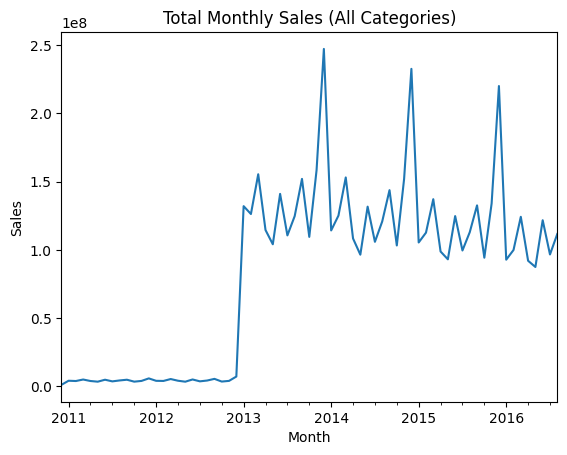

,unique_id,y
5,A|A|M,854842390.0
42,B|C|W,660922180.0
65,C|C|W,649790668.0
11,A|C|ALL,354243738.0
29,A|J|Z,263460272.0
25,A|I|K,259709643.0
53,B|I|K,195120144.0
70,C|G|F,176420725.0
52,B|I|G,133206623.0
13,A|D|ALL,124477709.0


Selected important series (top 2 per Category1):


,Category1,Category2,Category3,unique_id,y
5,A,A,M,A|A|M,257064429.0
65,C,C,W,C|C|W,161339542.0
42,B,C,W,B|C|W,135046917.0
11,A,C,ALL,A|C|ALL,81482297.0
53,B,I,K,B|I|K,53413383.0
70,C,G,F,C|G|F,42898334.0


,unique_id,smape_autoarima,smape_ets,best_model
3,B|I|K,0.113009,0.127660,AutoARIMA
2,B|C|W,0.120553,0.132832,AutoARIMA
0,A|A|M,0.172509,0.183370,AutoARIMA
5,C|G|F,0.177768,0.123410,ETS
4,C|C|W,0.187973,0.214945,AutoARIMA
1,A|C|ALL,0.308645,0.292995,ETS


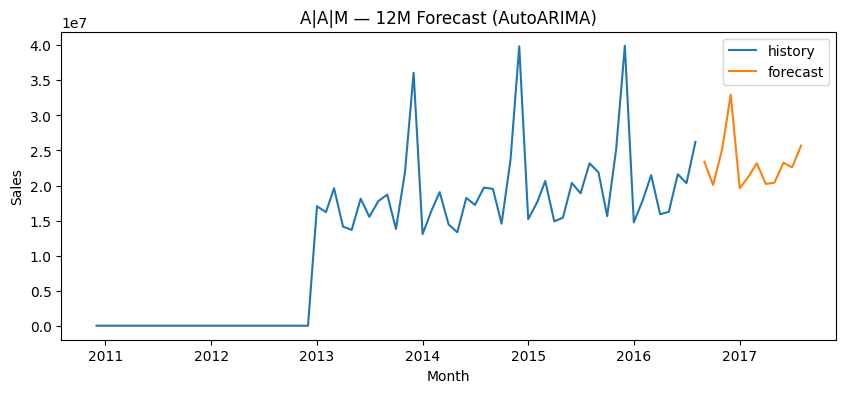

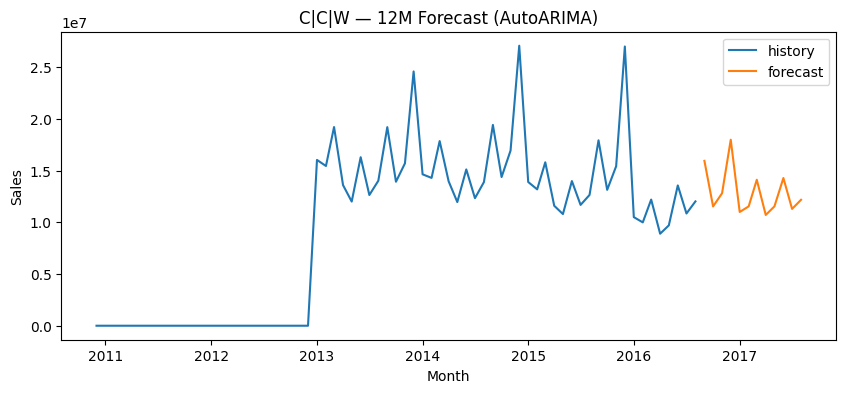

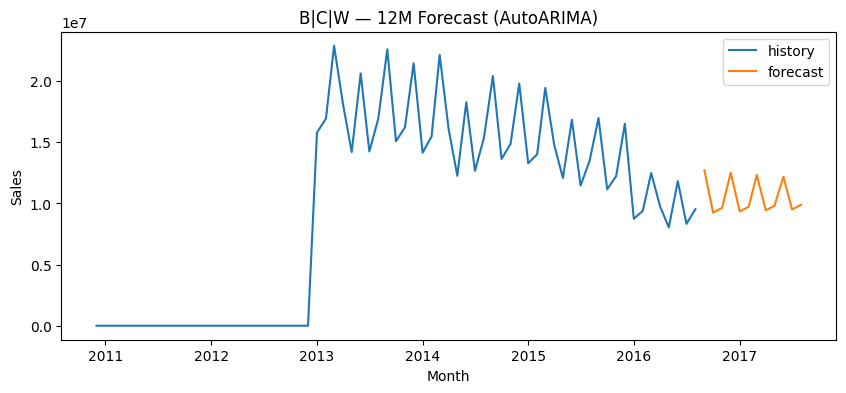

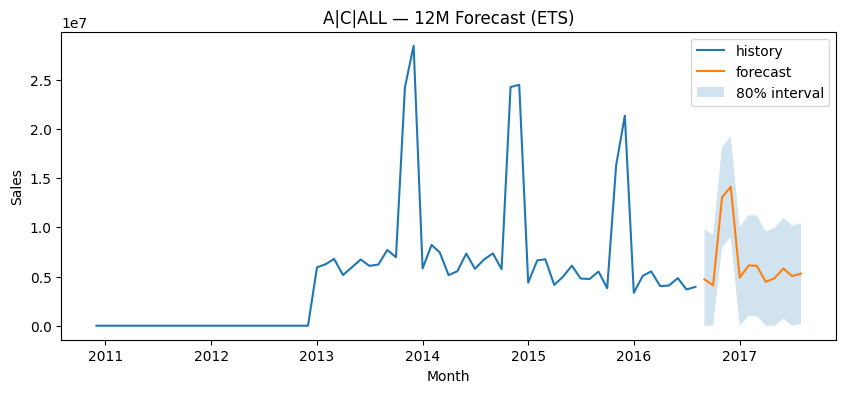

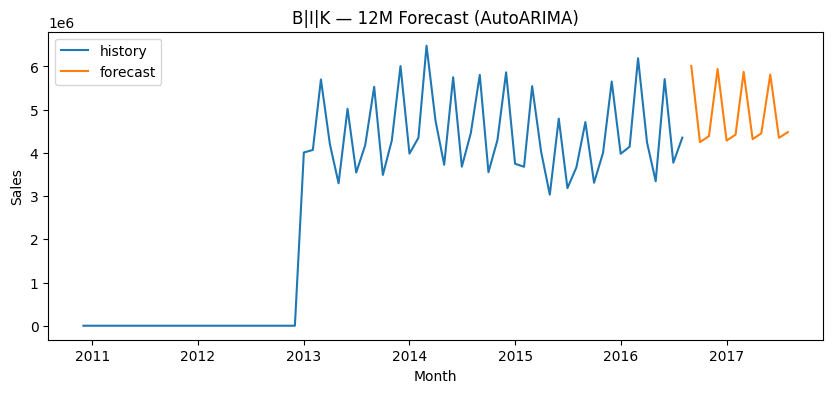

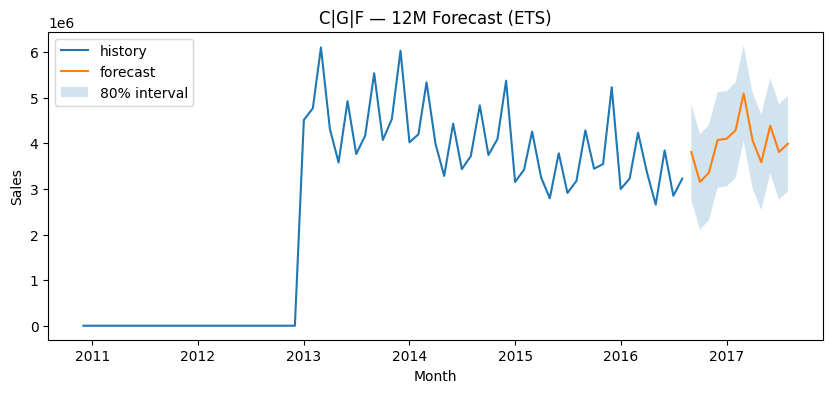

Saved: logitech_forecast_12mo_class_style.csv
Saved: logitech_model_comparison_class_style.csv


In [ ]:

# ----------------------------
# 3) Clean + reshape to Nixtla format: [unique_id, ds, y]
# ----------------------------
# Identify month columns like "10-Dec", "11-Jan", ...
month_cols = [c for c in df_raw.columns if re.match(r"^\d{2}-[A-Za-z]{3}$", str(c))]

# Drop blank category rows (common in these take-home files)
df = df_raw.dropna(subset=["Category1", "Category2"], how="all").copy()
df["Category3"] = df["Category3"].fillna("ALL")

# Wide -> long
long = df.melt(
    id_vars=["Category1", "Category2", "Category3"],
    value_vars=month_cols,
    var_name="month_str",
    value_name="sales"
)

# Parse month + coerce numeric
long["ds"] = pd.to_datetime(long["month_str"], format="%y-%b")
long["sales"] = pd.to_numeric(long["sales"], errors="coerce").fillna(0.0)

# Basic business rule: negative sales likely returns/adjustments in mock data
long["y"] = long["sales"].clip(lower=0.0)

# Create Nixtla-style unique series id
long["unique_id"] = (
    long["Category1"].astype(str) + "|" +
    long["Category2"].astype(str) + "|" +
    long["Category3"].astype(str)
)

# Aggregate duplicates (some series appear multiple times in raw file)
# -> this is IMPORTANT to avoid non-unique date index issues
ts = (
    long.groupby(["unique_id", "ds"], as_index=False)["y"]
        .sum()
        .sort_values(["unique_id", "ds"])
)

# Enforce monthly frequency start-of-month (StatsForecast expects regular time)
# If dates are already month start, this is fine; otherwise normalize:
ts["ds"] = ts["ds"].dt.to_period("M").dt.to_timestamp()

print("Tidy TS shape:", ts.shape)
print("Unique series:", ts["unique_id"].nunique())
print("Date range:", ts["ds"].min().date(), "→", ts["ds"].max().date())

# ----------------------------
# 4) Quick EDA (Day 11 style)
# ----------------------------
# Overall sales trend
overall = ts.groupby("ds", as_index=True)["y"].sum().sort_index()
overall.plot()
plt.title("Total Monthly Sales (All Categories)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# Concentration: total sales by series (top 10)
series_total = ts.groupby("unique_id", as_index=False)["y"].sum().sort_values("y", ascending=False)
display(series_total.head(10))

# ----------------------------
# 5) Pick “most important product categories” (open-ended by design)
# Strategy (interview-friendly):
#   - Compute last 12 months sales per series
#   - Pick top N overall OR top k per Category1 for coverage
# Here: top 2 per Category1 (coverage) like we discussed.
# ----------------------------
max_ds = ts["ds"].max()
start12 = max_ds - pd.DateOffset(months=11)

last12 = ts[(ts["ds"] >= start12) & (ts["ds"] <= max_ds)].copy()

# Reattach category levels for reporting
cats = long[["unique_id", "Category1", "Category2", "Category3"]].drop_duplicates()
last12 = last12.merge(cats, on="unique_id", how="left")

imp = (
    last12.groupby(["Category1", "Category2", "Category3", "unique_id"], as_index=False)["y"]
          .sum()
          .sort_values("y", ascending=False)
)

top_series = (
    imp.sort_values("y", ascending=False)
       .groupby("Category1", as_index=False)
       .head(2)
       .sort_values("y", ascending=False)
)

selected = top_series["unique_id"].tolist()
print("Selected important series (top 2 per Category1):")
display(top_series)

# Visualize a handful (Day 11 plot_series style)
plot_df = ts[ts["unique_id"].isin(selected)]
plot_series(plot_df, max_ids=6)  # shows up to 6
plt.show()

# ----------------------------
# 6) Train/Test split (Last 12 months as test) — class-style
# ----------------------------
def train_test_split_last_n(df, n=12):
    # df is tidy with columns: unique_id, ds, y
    out = []
    for uid, g in df.groupby("unique_id"):
        g = g.sort_values("ds")
        if len(g) <= n + 24:  # guard for small series
            n_eff = max(6, min(n, len(g)//5))
        else:
            n_eff = n
        train = g.iloc[:-n_eff].copy()
        test  = g.iloc[-n_eff:].copy()
        out.append((uid, train, test))
    return out

splits = train_test_split_last_n(plot_df, n=12)

# ----------------------------
# 7) Metric: sMAPE (used in class a lot; also interview-friendly)
# ----------------------------
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred))
    denom = np.where(denom == 0, 1.0, denom)
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom))

# ----------------------------
# 8) Model A: StatsForecast + AutoARIMA (Day 11 structure)
#    Rolling-origin evaluation (expanding window, 1-step ahead)
# ----------------------------
def rolling_cv_autoarima_one_step(train_df, test_df, season_length=12):
    """
    Expanding-window 1-step rolling predictions across test horizon.
    train_df/test_df: tidy for a single uid (unique_id, ds, y)
    Returns: preds aligned to test_df['ds'], plus sMAPE
    """
    uid = train_df["unique_id"].iloc[0]
    full = pd.concat([train_df, test_df], ignore_index=True).sort_values("ds")

    # We'll generate 1-step forecasts sequentially (fast enough for interview)
    preds = []
    test_dates = list(test_df["ds"])
    split_idx = len(train_df)

    for i in range(len(test_df)):
        sub = full.iloc[: split_idx + i].copy()

        sf = StatsForecast(
            models=[AutoARIMA(season_length=season_length)],
            freq="MS",
            n_jobs=1
        )
        # Forecast one step
        fc = sf.forecast(df=sub, h=1)
        preds.append(float(fc["AutoARIMA"].iloc[0]))

    y_true = test_df["y"].values
    y_pred = np.array(preds)
    return y_pred, smape(y_true, y_pred)

# ----------------------------
# 9) Model B: ETS (Holt-Winters) (Day 9 style)
#    Rolling-origin evaluation (expanding window, 1-step ahead)
# ----------------------------
def rolling_cv_ets_one_step(train_df, test_df, seasonal_periods=12):
    uid = train_df["unique_id"].iloc[0]
    full = pd.concat([train_df, test_df], ignore_index=True).sort_values("ds")

    preds = []
    split_idx = len(train_df)

    for i in range(len(test_df)):
        sub = full.iloc[: split_idx + i].copy()
        y = sub.set_index("ds")["y"].asfreq("MS")

        # Try seasonal ETS first; fall back to trend-only if needed
        try:
            model = ExponentialSmoothing(
                y, trend="add", seasonal="add", seasonal_periods=seasonal_periods
            ).fit(optimized=True, use_brute=True)
        except Exception:
            model = ExponentialSmoothing(y, trend="add").fit(optimized=True)

        preds.append(float(model.forecast(1).iloc[0]))

    y_true = test_df["y"].values
    y_pred = np.array(preds)
    return y_pred, smape(y_true, y_pred)

# ----------------------------
# 10) Run evaluation + choose best per series
# ----------------------------
results = []
all_forecasts = []

H = 12  # final forecast horizon

for uid, train_df, test_df in splits:
    # Evaluate AutoARIMA
    arima_pred, arima_smape = rolling_cv_autoarima_one_step(train_df, test_df, season_length=12)

    # Evaluate ETS
    ets_pred, ets_smape = rolling_cv_ets_one_step(train_df, test_df, seasonal_periods=12)

    best = "AutoARIMA" if arima_smape <= ets_smape else "ETS"

    results.append({
        "unique_id": uid,
        "smape_autoarima": arima_smape,
        "smape_ets": ets_smape,
        "best_model": best
    })

    # ----------------------------
    # Fit BEST model on full history + forecast H months ahead
    # ----------------------------
    series_full = plot_df[plot_df["unique_id"] == uid].sort_values("ds").copy()

    future_ds = pd.date_range(series_full["ds"].max() + pd.offsets.MonthBegin(1), periods=H, freq="MS")

    if best == "AutoARIMA":
        sf = StatsForecast(
            models=[AutoARIMA(season_length=12)],
            freq="MS",
            n_jobs=1
        )
        fc = sf.forecast(df=series_full, h=H)

        yhat = fc["AutoARIMA"].values.astype(float)
        # StatsForecast doesn’t always expose simple CIs the same way across versions;
        # keep it interview-clean: point forecasts (you can add intervals if your class did)
        lo = np.full(H, np.nan)
        hi = np.full(H, np.nan)

    else:
        y = series_full.set_index("ds")["y"].asfreq("MS")
        try:
            model = ExponentialSmoothing(y, trend="add", seasonal="add", seasonal_periods=12)\
                    .fit(optimized=True, use_brute=True)
        except Exception:
            model = ExponentialSmoothing(y, trend="add").fit(optimized=True)

        fc = model.forecast(H)
        yhat = fc.values.astype(float)

        # Simple ~80% interval via residual std (same as earlier notebook approach)
        resid = (y - model.fittedvalues).dropna()
        sigma = float(resid.std(ddof=1)) if len(resid) > 2 else 0.0
        lo = np.clip(yhat - 1.28 * sigma, 0, None)
        hi = np.clip(yhat + 1.28 * sigma, 0, None)

    # Build forecast table
    # Split categories from uid
    c1, c2, c3 = uid.split("|")
    for d, yh, l, u in zip(future_ds, yhat, lo, hi):
        all_forecasts.append({
            "Category1": c1,
            "Category2": c2,
            "Category3": c3,
            "unique_id": uid,
            "ds": d,
            "yhat": float(max(yh, 0.0)),
            "yhat_lower80": (float(l) if np.isfinite(l) else np.nan),
            "yhat_upper80": (float(u) if np.isfinite(u) else np.nan),
            "model": best
        })

# Results summary
results_df = pd.DataFrame(results).sort_values("smape_autoarima")
display(results_df)

# ----------------------------
# 11) Plot: history + forecast per series (class-style)
# ----------------------------
forecast_df = pd.DataFrame(all_forecasts).sort_values(["unique_id", "ds"])

for uid in selected:
    hist = plot_df[plot_df["unique_id"] == uid].sort_values("ds")
    fc = forecast_df[forecast_df["unique_id"] == uid].sort_values("ds")

    plt.figure(figsize=(10, 4))
    plt.plot(hist["ds"], hist["y"], label="history")
    plt.plot(fc["ds"], fc["yhat"], label="forecast")

    if fc["yhat_lower80"].notna().any():
        plt.fill_between(fc["ds"], fc["yhat_lower80"], fc["yhat_upper80"], alpha=0.2, label="80% interval")

    best_model = results_df.loc[results_df["unique_id"] == uid, "best_model"].iloc[0]
    plt.title(f"{uid} — 12M Forecast ({best_model})")
    plt.xlabel("Month")
    plt.ylabel("Sales")
    plt.legend()
    plt.show()

# ----------------------------
# 12) Export deliverables
# ----------------------------
forecast_df_out = forecast_df.copy()
forecast_df_out["ds"] = forecast_df_out["ds"].dt.date.astype(str)

forecast_df_out.to_csv("logitech_forecast_12mo_class_style.csv", index=False)
print("Saved: logitech_forecast_12mo_class_style.csv")

# Optional: also save selected series list + model choice
results_df.to_csv("logitech_model_comparison_class_style.csv", index=False)
print("Saved: logitech_model_comparison_class_style.csv")

Tidy TS shape: (5382, 3)
Unique series: 78
Date range: 2010-12-01 → 2016-08-01


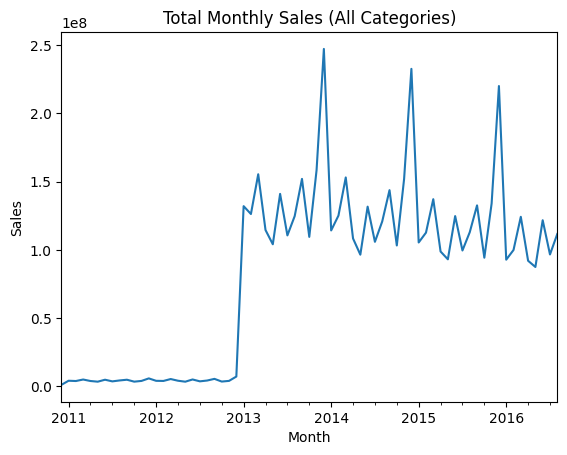

,unique_id,y
5,A|A|M,854842390.0
42,B|C|W,660922180.0
65,C|C|W,649790668.0
11,A|C|ALL,354243738.0
29,A|J|Z,263460272.0
25,A|I|K,259709643.0
53,B|I|K,195120144.0
70,C|G|F,176420725.0
52,B|I|G,133206623.0
13,A|D|ALL,124477709.0


Selected important series (top 2 per Category1):


,Category1,Category2,Category3,unique_id,y
5,A,A,M,A|A|M,257064429.0
65,C,C,W,C|C|W,161339542.0
42,B,C,W,B|C|W,135046917.0
11,A,C,ALL,A|C|ALL,81482297.0
53,B,I,K,B|I|K,53413383.0
70,C,G,F,C|G|F,42898334.0


,unique_id,smape_autoarima,smape_ets,best_model
3,B|I|K,0.113009,0.127660,AutoARIMA
2,B|C|W,0.120553,0.132832,AutoARIMA
0,A|A|M,0.172509,0.183370,AutoARIMA
5,C|G|F,0.177768,0.123410,ETS
4,C|C|W,0.187973,0.214945,AutoARIMA
1,A|C|ALL,0.308645,0.292995,ETS


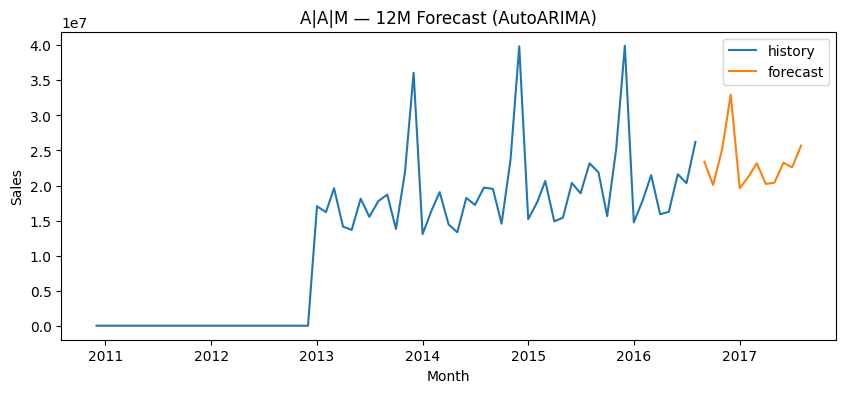

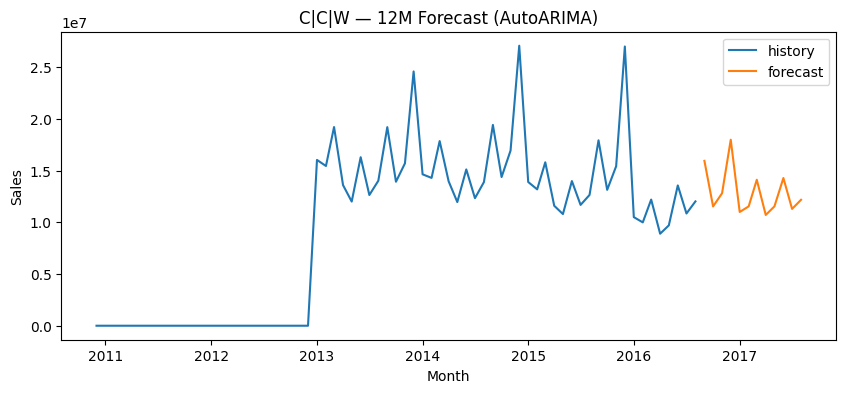

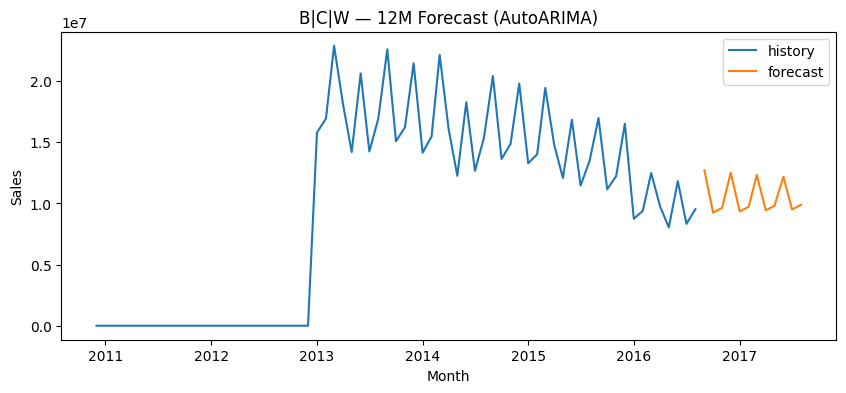

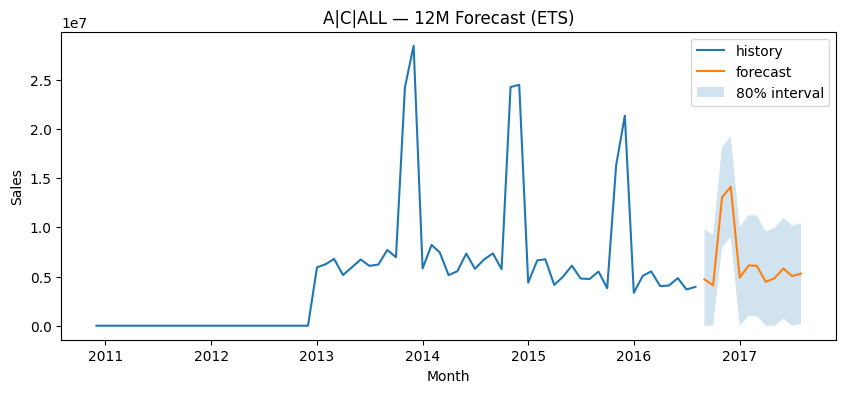

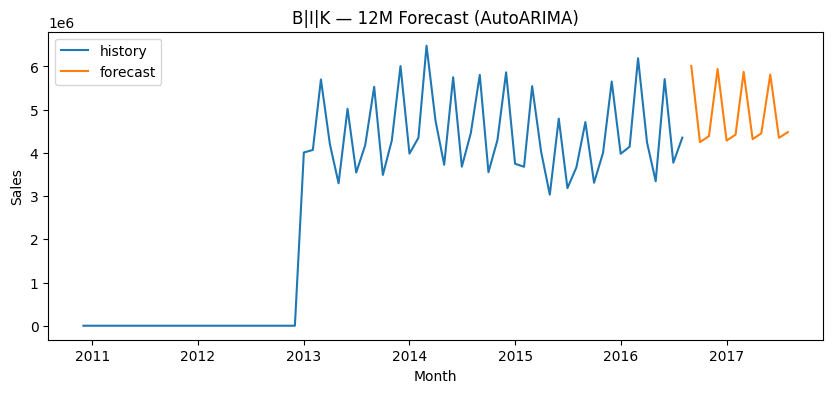

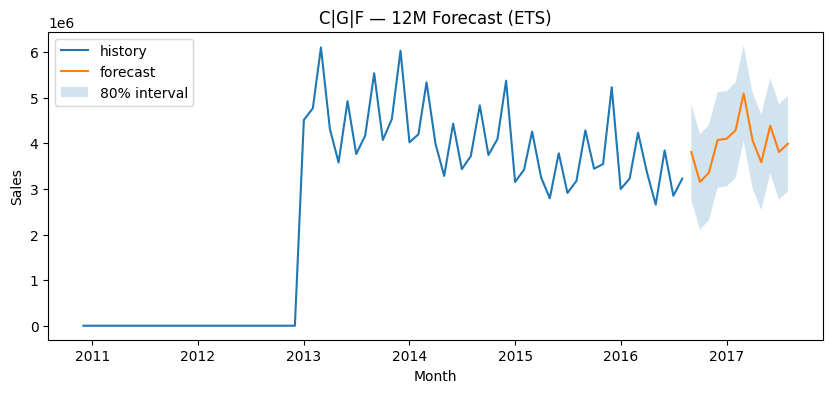

Saved: logitech_forecast_12mo_class_style.csv
Saved: logitech_model_comparison_class_style.csv


In [ ]:
# ----------------------------
# 3) Clean + reshape to Nixtla format: [unique_id, ds, y]
# ----------------------------
# Identify month columns like "10-Dec", "11-Jan", ...
month_cols = [c for c in df_raw.columns if re.match(r"^\d{2}-[A-Za-z]{3}$", str(c))]

# Drop blank category rows (common in these take-home files)
df = df_raw.dropna(subset=["Category1", "Category2"], how="all").copy()
df["Category3"] = df["Category3"].fillna("ALL")

# Wide -> long
long = df.melt(
    id_vars=["Category1", "Category2", "Category3"],
    value_vars=month_cols,
    var_name="month_str",
    value_name="sales"
)

# Parse month + coerce numeric
long["ds"] = pd.to_datetime(long["month_str"], format="%y-%b")
long["sales"] = pd.to_numeric(long["sales"], errors="coerce").fillna(0.0)

# Basic business rule: negative sales likely returns/adjustments in mock data
long["y"] = long["sales"].clip(lower=0.0)

# Create Nixtla-style unique series id
long["unique_id"] = (
    long["Category1"].astype(str) + "|" +
    long["Category2"].astype(str) + "|" +
    long["Category3"].astype(str)
)

# Aggregate duplicates (some series appear multiple times in raw file)
# -> this is IMPORTANT to avoid non-unique date index issues
ts = (
    long.groupby(["unique_id", "ds"], as_index=False)["y"]
        .sum()
        .sort_values(["unique_id", "ds"])
)

# Enforce monthly frequency start-of-month (StatsForecast expects regular time)
# If dates are already month start, this is fine; otherwise normalize:
ts["ds"] = ts["ds"].dt.to_period("M").dt.to_timestamp()

print("Tidy TS shape:", ts.shape)
print("Unique series:", ts["unique_id"].nunique())
print("Date range:", ts["ds"].min().date(), "→", ts["ds"].max().date())

# ----------------------------
# 4) Quick EDA (Day 11 style)
# ----------------------------
# Overall sales trend
overall = ts.groupby("ds", as_index=True)["y"].sum().sort_index()
overall.plot()
plt.title("Total Monthly Sales (All Categories)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# Concentration: total sales by series (top 10)
series_total = ts.groupby("unique_id", as_index=False)["y"].sum().sort_values("y", ascending=False)
display(series_total.head(10))

# ----------------------------
# 5) Pick “most important product categories” (open-ended by design)
# Strategy (interview-friendly):
#   - Compute last 12 months sales per series
#   - Pick top N overall OR top k per Category1 for coverage
# Here: top 2 per Category1 (coverage) like we discussed.
# ----------------------------
max_ds = ts["ds"].max()
start12 = max_ds - pd.DateOffset(months=11)

last12 = ts[(ts["ds"] >= start12) & (ts["ds"] <= max_ds)].copy()

# Reattach category levels for reporting
cats = long[["unique_id", "Category1", "Category2", "Category3"]].drop_duplicates()
last12 = last12.merge(cats, on="unique_id", how="left")

imp = (
    last12.groupby(["Category1", "Category2", "Category3", "unique_id"], as_index=False)["y"]
          .sum()
          .sort_values("y", ascending=False)
)

top_series = (
    imp.sort_values("y", ascending=False)
       .groupby("Category1", as_index=False)
       .head(2)
       .sort_values("y", ascending=False)
)

selected = top_series["unique_id"].tolist()
print("Selected important series (top 2 per Category1):")
display(top_series)

# Visualize a handful (Day 11 plot_series style)
plot_df = ts[ts["unique_id"].isin(selected)]
plot_series(plot_df, max_ids=6)  # shows up to 6
plt.show()

# ----------------------------
# 6) Train/Test split (Last 12 months as test) — class-style
# ----------------------------
def train_test_split_last_n(df, n=12):
    # df is tidy with columns: unique_id, ds, y
    out = []
    for uid, g in df.groupby("unique_id"):
        g = g.sort_values("ds")
        if len(g) <= n + 24:  # guard for small series
            n_eff = max(6, min(n, len(g)//5))
        else:
            n_eff = n
        train = g.iloc[:-n_eff].copy()
        test  = g.iloc[-n_eff:].copy()
        out.append((uid, train, test))
    return out

splits = train_test_split_last_n(plot_df, n=12)

# ----------------------------
# 7) Metric: sMAPE (used in class a lot; also interview-friendly)
# ----------------------------
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred))
    denom = np.where(denom == 0, 1.0, denom)
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom))

# ----------------------------
# 8) Model A: StatsForecast + AutoARIMA (Day 11 structure)
#    Rolling-origin evaluation (expanding window, 1-step ahead)
# ----------------------------
def rolling_cv_autoarima_one_step(train_df, test_df, season_length=12):
    """
    Expanding-window 1-step rolling predictions across test horizon.
    train_df/test_df: tidy for a single uid (unique_id, ds, y)
    Returns: preds aligned to test_df['ds'], plus sMAPE
    """
    uid = train_df["unique_id"].iloc[0]
    full = pd.concat([train_df, test_df], ignore_index=True).sort_values("ds")

    # We'll generate 1-step forecasts sequentially (fast enough for interview)
    preds = []
    test_dates = list(test_df["ds"])
    split_idx = len(train_df)

    for i in range(len(test_df)):
        sub = full.iloc[: split_idx + i].copy()

        sf = StatsForecast(
            models=[AutoARIMA(season_length=season_length)],
            freq="MS",
            n_jobs=1
        )
        # Forecast one step
        fc = sf.forecast(df=sub, h=1)
        preds.append(float(fc["AutoARIMA"].iloc[0]))

    y_true = test_df["y"].values
    y_pred = np.array(preds)
    return y_pred, smape(y_true, y_pred)

# ----------------------------
# 9) Model B: ETS (Holt-Winters) (Day 9 style)
#    Rolling-origin evaluation (expanding window, 1-step ahead)
# ----------------------------
def rolling_cv_ets_one_step(train_df, test_df, seasonal_periods=12):
    uid = train_df["unique_id"].iloc[0]
    full = pd.concat([train_df, test_df], ignore_index=True).sort_values("ds")

    preds = []
    split_idx = len(train_df)

    for i in range(len(test_df)):
        sub = full.iloc[: split_idx + i].copy()
        y = sub.set_index("ds")["y"].asfreq("MS")

        # Try seasonal ETS first; fall back to trend-only if needed
        try:
            model = ExponentialSmoothing(
                y, trend="add", seasonal="add", seasonal_periods=seasonal_periods
            ).fit(optimized=True, use_brute=True)
        except Exception:
            model = ExponentialSmoothing(y, trend="add").fit(optimized=True)

        preds.append(float(model.forecast(1).iloc[0]))

    y_true = test_df["y"].values
    y_pred = np.array(preds)
    return y_pred, smape(y_true, y_pred)

# ----------------------------
# 10) Run evaluation + choose best per series
# ----------------------------
results = []
all_forecasts = []

H = 12  # final forecast horizon

for uid, train_df, test_df in splits:
    # Evaluate AutoARIMA
    arima_pred, arima_smape = rolling_cv_autoarima_one_step(train_df, test_df, season_length=12)

    # Evaluate ETS
    ets_pred, ets_smape = rolling_cv_ets_one_step(train_df, test_df, seasonal_periods=12)

    best = "AutoARIMA" if arima_smape <= ets_smape else "ETS"

    results.append({
        "unique_id": uid,
        "smape_autoarima": arima_smape,
        "smape_ets": ets_smape,
        "best_model": best
    })

    # ----------------------------
    # Fit BEST model on full history + forecast H months ahead
    # ----------------------------
    series_full = plot_df[plot_df["unique_id"] == uid].sort_values("ds").copy()

    future_ds = pd.date_range(series_full["ds"].max() + pd.offsets.MonthBegin(1), periods=H, freq="MS")

    if best == "AutoARIMA":
        sf = StatsForecast(
            models=[AutoARIMA(season_length=12)],
            freq="MS",
            n_jobs=1
        )
        fc = sf.forecast(df=series_full, h=H)

        yhat = fc["AutoARIMA"].values.astype(float)
        # StatsForecast doesn’t always expose simple CIs the same way across versions;
        # keep it interview-clean: point forecasts (you can add intervals if your class did)
        lo = np.full(H, np.nan)
        hi = np.full(H, np.nan)

    else:
        y = series_full.set_index("ds")["y"].asfreq("MS")
        try:
            model = ExponentialSmoothing(y, trend="add", seasonal="add", seasonal_periods=12)\
                    .fit(optimized=True, use_brute=True)
        except Exception:
            model = ExponentialSmoothing(y, trend="add").fit(optimized=True)

        fc = model.forecast(H)
        yhat = fc.values.astype(float)

        # Simple ~80% interval via residual std (same as earlier notebook approach)
        resid = (y - model.fittedvalues).dropna()
        sigma = float(resid.std(ddof=1)) if len(resid) > 2 else 0.0
        lo = np.clip(yhat - 1.28 * sigma, 0, None)
        hi = np.clip(yhat + 1.28 * sigma, 0, None)

    # Build forecast table
    # Split categories from uid
    c1, c2, c3 = uid.split("|")
    for d, yh, l, u in zip(future_ds, yhat, lo, hi):
        all_forecasts.append({
            "Category1": c1,
            "Category2": c2,
            "Category3": c3,
            "unique_id": uid,
            "ds": d,
            "yhat": float(max(yh, 0.0)),
            "yhat_lower80": (float(l) if np.isfinite(l) else np.nan),
            "yhat_upper80": (float(u) if np.isfinite(u) else np.nan),
            "model": best
        })

# Results summary
results_df = pd.DataFrame(results).sort_values("smape_autoarima")
display(results_df)

# ----------------------------
# 11) Plot: history + forecast per series (class-style)
# ----------------------------
forecast_df = pd.DataFrame(all_forecasts).sort_values(["unique_id", "ds"])

for uid in selected:
    hist = plot_df[plot_df["unique_id"] == uid].sort_values("ds")
    fc = forecast_df[forecast_df["unique_id"] == uid].sort_values("ds")

    plt.figure(figsize=(10, 4))
    plt.plot(hist["ds"], hist["y"], label="history")
    plt.plot(fc["ds"], fc["yhat"], label="forecast")

    if fc["yhat_lower80"].notna().any():
        plt.fill_between(fc["ds"], fc["yhat_lower80"], fc["yhat_upper80"], alpha=0.2, label="80% interval")

    best_model = results_df.loc[results_df["unique_id"] == uid, "best_model"].iloc[0]
    plt.title(f"{uid} — 12M Forecast ({best_model})")
    plt.xlabel("Month")
    plt.ylabel("Sales")
    plt.legend()
    plt.show()

# ----------------------------
# 12) Export deliverables
# ----------------------------
forecast_df_out = forecast_df.copy()
forecast_df_out["ds"] = forecast_df_out["ds"].dt.date.astype(str)

forecast_df_out.to_csv("logitech_forecast_12mo_class_style.csv", index=False)
print("Saved: logitech_forecast_12mo_class_style.csv")

# Optional: also save selected series list + model choice
results_df.to_csv("logitech_model_comparison_class_style.csv", index=False)
print("Saved: logitech_model_comparison_class_style.csv")


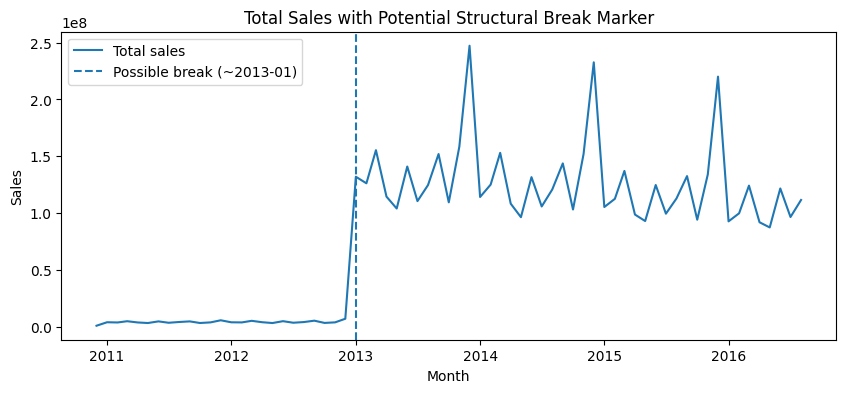

Structural break summary:
  Pre-2013 mean monthly sales : 4,229,378
  Post-2013 mean monthly sales: 126,215,973
  Approx level lift           : 2,884.3%
  Pre-2013 median monthly sales : 4,031,199
  Post-2013 median monthly sales: 117,653,208
  Approx median lift            : 2,818.6%


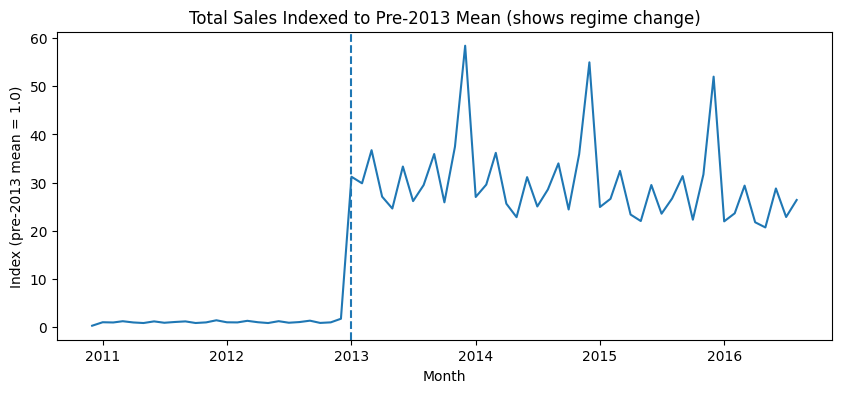

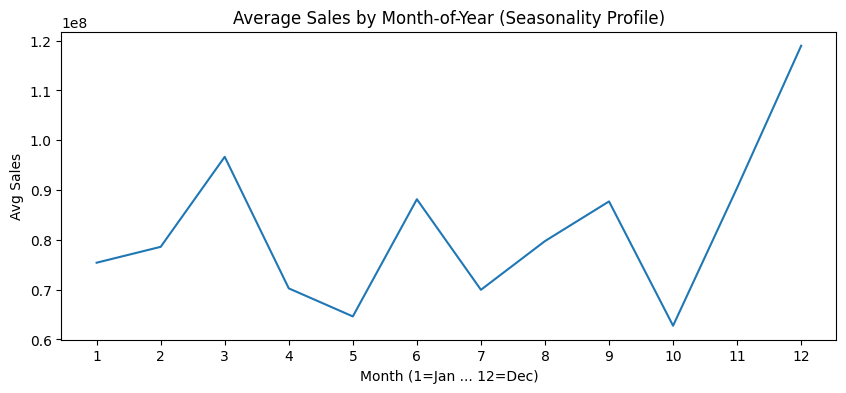

,month,y,seasonal_index
0,1,7.541351e+07,0.919476
1,2,7.859904e+07,0.958315
2,3,9.667071e+07,1.178653
3,4,7.026172e+07,0.856663
4,5,6.463251e+07,0.788029
5,6,8.815436e+07,1.074818
6,7,6.997456e+07,0.853162
7,8,7.975244e+07,0.972378
8,9,8.771437e+07,1.069454
9,10,6.276473e+07,0.765256


Seasonality summary:
  Avg Q4 month sales    : 90,729,685
  Avg non-Q4 month sales: 79,019,247
  Q4 uplift vs non-Q4   : 14.8%


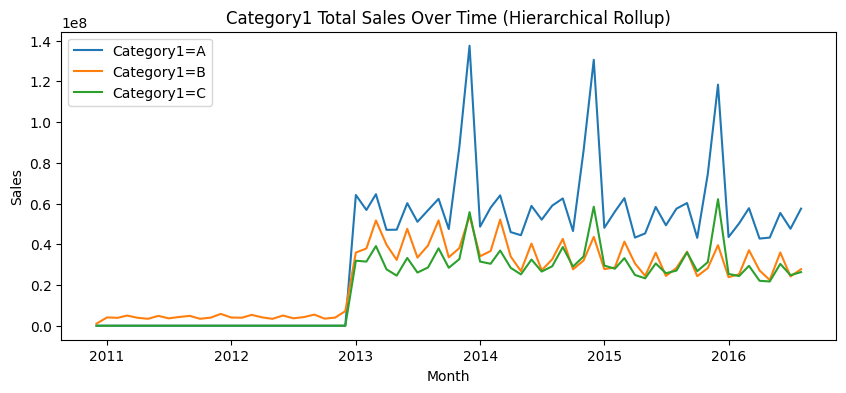

,Category1,y
0,A,694193734.0
2,C,360685967.0
1,B,352120668.0



EXEC-SUMMARY BULLETS (paste into top of notebook):
- Structural break: total sales show a level shift around 2013-01-01 (post-2013 mean ~ 2,884.3% above pre-2013).
- Seasonality: month-of-year profile indicates Q4 uplift (Oct–Dec avg ~ 14.8% above non-Q4), supporting seasonal models.
- Hierarchy: data is Category1/2/3; if totals are needed, consider hierarchical forecasting + reconciliation (bottom-up/top-down/MinT).


In [ ]:
# ============================================================
# A) Structural Break, B) Seasonality, C) Hierarchy
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes you already have:
# - ts: tidy dataframe with columns ["unique_id","ds","y"]
# - long or cats mapping (optional)
# - selected: list of important series unique_id (top series)
# - overall: overall total series indexed by ds (if you created it earlier)

# ----------------------------
# A) STRUCTURAL BREAK CHECK (Regime shift around 2013)
# ----------------------------
# Purpose (write-up):
# "There is a clear level shift around early 2013 in total sales. This can happen due to
#  changes in measurement/reporting, channel inclusion, product portfolio expansion, or data processing.
#  I flag it explicitly and quantify it because it affects model assumptions and forecast stability."

# 1) Recompute overall if needed
overall = ts.groupby("ds", as_index=True)["y"].sum().sort_index()

# 2) Plot overall with a reference line at 2013-01-01
break_date = pd.Timestamp("2013-01-01")

plt.figure(figsize=(10,4))
plt.plot(overall.index, overall.values, label="Total sales")
plt.axvline(break_date, linestyle="--", label="Possible break (~2013-01)")
plt.title("Total Sales with Potential Structural Break Marker")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.show()

# 3) Quantify magnitude of shift: compare mean before vs after 2013
pre = overall[overall.index < break_date]
post = overall[overall.index >= break_date]

pre_mean = pre.mean()
post_mean = post.mean()
lift = (post_mean / pre_mean) - 1 if pre_mean != 0 else np.nan

print("Structural break summary:")
print(f"  Pre-2013 mean monthly sales : {pre_mean:,.0f}")
print(f"  Post-2013 mean monthly sales: {post_mean:,.0f}")
print(f"  Approx level lift           : {lift*100:,.1f}%")

# Optional: show medians too (less sensitive to spikes)
pre_med = pre.median()
post_med = post.median()
lift_med = (post_med / pre_med) - 1 if pre_med != 0 else np.nan

print(f"  Pre-2013 median monthly sales : {pre_med:,.0f}")
print(f"  Post-2013 median monthly sales: {post_med:,.0f}")
print(f"  Approx median lift            : {lift_med*100:,.1f}%")

# 4) A simple ratio plot to make the break obvious
plt.figure(figsize=(10,4))
plt.plot(overall.index, overall.values / pre_mean)
plt.axvline(break_date, linestyle="--")
plt.title("Total Sales Indexed to Pre-2013 Mean (shows regime change)")
plt.xlabel("Month")
plt.ylabel("Index (pre-2013 mean = 1.0)")
plt.show()

# Write-up bullet you can paste:
# - "Total sales show a sharp level shift around early 2013 (post-2013 mean is ~X% higher than pre-2013).
#    This could reflect a measurement/reporting change, channel expansion, or portfolio change.
#    I flag it explicitly because it can bias trend/seasonality estimation; models were fit on the full series
#    but this should be validated with business context."

# ----------------------------
# B) SEASONALITY CHECK (Q4 spikes / annual seasonality)
# ----------------------------
# Purpose (write-up):
# "Many top categories display annual seasonality, especially Q4 uplift.
#  I quantify it by month-of-year averages and a seasonal index."

# 1) Month-of-year profile for overall sales
overall_df = overall.reset_index()
overall_df["month"] = overall_df["ds"].dt.month

moy = overall_df.groupby("month", as_index=False)["y"].mean()

plt.figure(figsize=(10,4))
plt.plot(moy["month"], moy["y"])
plt.title("Average Sales by Month-of-Year (Seasonality Profile)")
plt.xlabel("Month (1=Jan ... 12=Dec)")
plt.ylabel("Avg Sales")
plt.xticks(range(1,13))
plt.show()

# 2) Seasonal index (month mean / overall mean)
overall_mean = overall_df["y"].mean()
moy["seasonal_index"] = moy["y"] / overall_mean

display(moy)

# 3) Compare Q4 vs non-Q4 average (simple business stat)
q4_mean = moy.loc[moy["month"].isin([10,11,12]), "y"].mean()
non_q4_mean = moy.loc[~moy["month"].isin([10,11,12]), "y"].mean()
q4_lift = (q4_mean / non_q4_mean) - 1 if non_q4_mean != 0 else np.nan

print("Seasonality summary:")
print(f"  Avg Q4 month sales    : {q4_mean:,.0f}")
print(f"  Avg non-Q4 month sales: {non_q4_mean:,.0f}")
print(f"  Q4 uplift vs non-Q4   : {q4_lift*100:,.1f}%")

# Write-up bullet you can paste:
# - "There is clear annual seasonality: month-of-year averages show Q4 uplift (Oct–Dec average is ~X% above non-Q4),
#    consistent with holiday-driven demand patterns. This supports including seasonal components in forecasts (ETS/SARIMA)."

# ----------------------------
# C) HIERARCHICAL CONSIDERATIONS (why mention it + quick checks)
# ----------------------------
# Purpose (write-up):
# "This is a 3-level hierarchy. If the business cares about totals at Category1/2,
#  we may want hierarchical forecasting + reconciliation so that child forecasts sum to parent forecasts."

# 1) Total by Category1 over time (quick rollup)
# We need Category1 mapping -> create a small mapping from your earlier melt if you have it
# If you don't have cats from earlier, rebuild it quickly from ts using the original long df.
try:
    cats_map = long[["unique_id", "Category1", "Category2", "Category3"]].drop_duplicates()
except NameError:
    # If "long" doesn't exist in your notebook, you can recreate mapping like this:
    # cats_map = ... (but you should already have it from earlier steps)
    cats_map = None

if cats_map is not None:
    ts_cat = ts.merge(cats_map[["unique_id", "Category1"]], on="unique_id", how="left")

    cat1_ts = ts_cat.groupby(["Category1", "ds"], as_index=False)["y"].sum()

    # Plot Category1 totals (3 lines typically: A/B/C)
    plt.figure(figsize=(10,4))
    for c1, g in cat1_ts.groupby("Category1"):
        g = g.sort_values("ds")
        plt.plot(g["ds"], g["y"], label=f"Category1={c1}")
    plt.title("Category1 Total Sales Over Time (Hierarchical Rollup)")
    plt.xlabel("Month")
    plt.ylabel("Sales")
    plt.legend()
    plt.show()

    # 2) Show that selected "important series" are a subset (coverage)
    #    (This is a talking point: we forecast key leaf series, but could forecast rollups too.)
    cat1_last12 = ts_cat[(ts_cat["ds"] >= start12) & (ts_cat["ds"] <= max_ds)]\
                    .groupby("Category1", as_index=False)["y"].sum()\
                    .sort_values("y", ascending=False)

    display(cat1_last12)

# Write-up bullets you can paste:
# - "The data is hierarchical (Category1/2/3). If leadership consumes forecasts at Category1/2 totals,
#    a production approach would forecast leaf-level series and then reconcile (bottom-up/top-down/MinT)
#    so child forecasts sum to parent totals."
# - "For this interview exercise, I forecasted the most important leaf series (top revenue drivers) and used
#    seasonal models appropriate for retail-like demand patterns."

# ----------------------------
# Optional: Executive-summary-ready text generator (prints bullets)
# ----------------------------
print("\nEXEC-SUMMARY BULLETS (paste into top of notebook):")
print(f"- Structural break: total sales show a level shift around {break_date.date()} (post-2013 mean ~ {lift*100:,.1f}% above pre-2013).")
print(f"- Seasonality: month-of-year profile indicates Q4 uplift (Oct–Dec avg ~ {q4_lift*100:,.1f}% above non-Q4), supporting seasonal models.")
print("- Hierarchy: data is Category1/2/3; if totals are needed, consider hierarchical forecasting + reconciliation (bottom-up/top-down/MinT).")

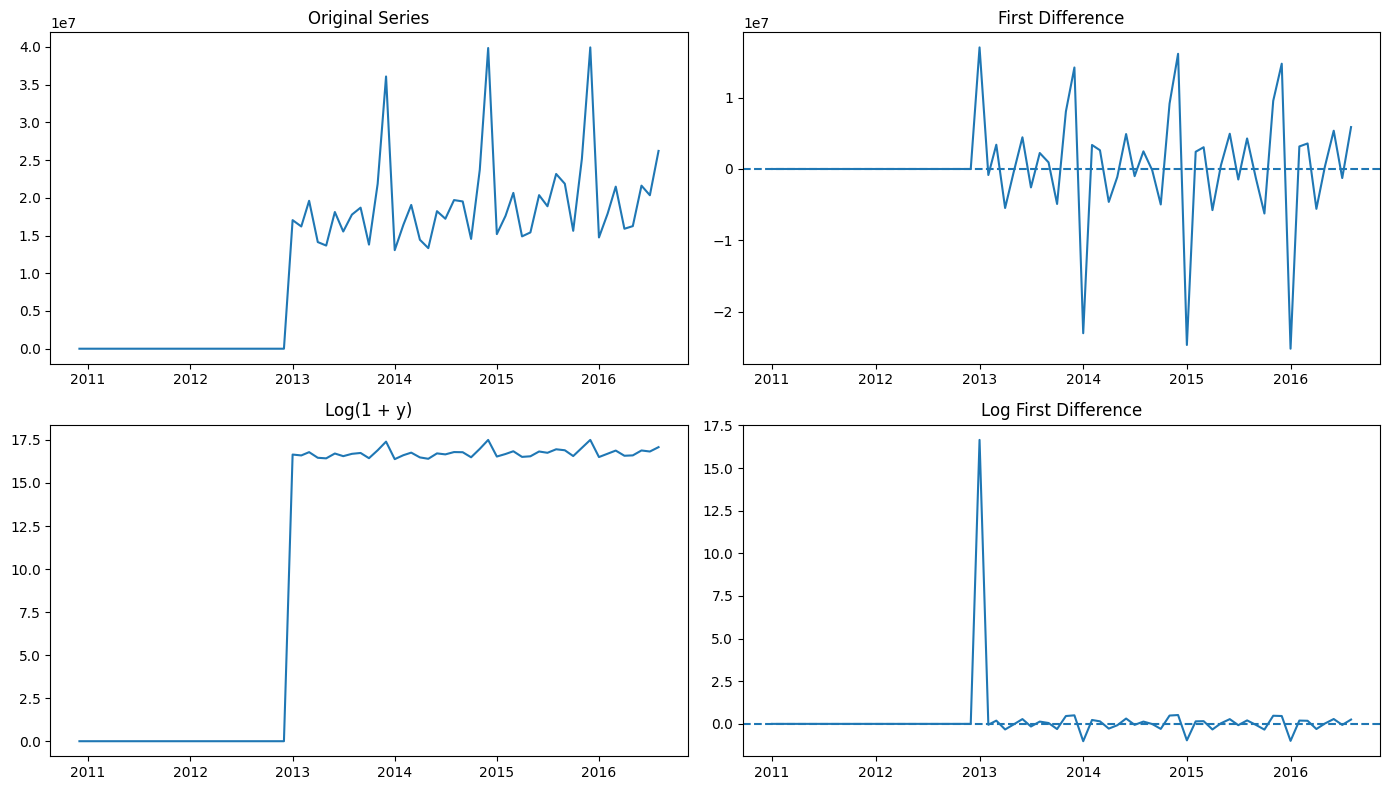

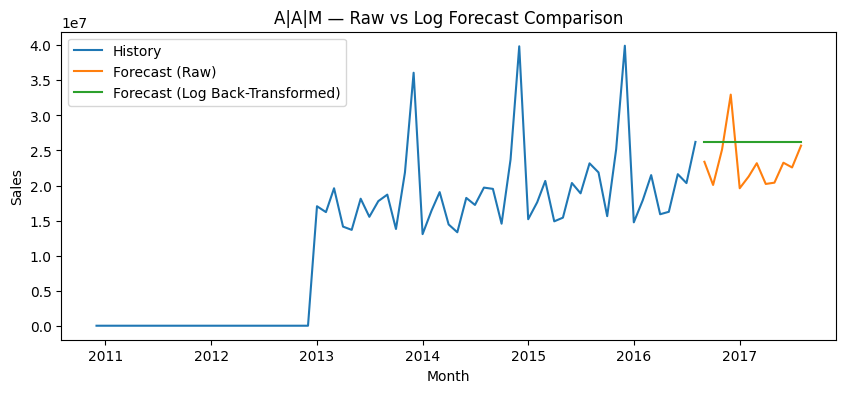

sMAPE Raw Model: 0.1725090765872913
sMAPE Log Model: 0.29377298710675326


In [ ]:
# ================================
# SINGLE BLOCK: Raw vs Log Modeling + Differencing + Forecast
# ================================

uid_example = selected[0]  # pick one important series
H = 12

# Extract series
series_full = plot_df[plot_df["unique_id"] == uid_example].sort_values("ds").copy()

# ---- Transformations ----
series_full["diff_1"] = series_full["y"].diff()
series_full["log_y"] = np.log1p(series_full["y"])
series_full["log_diff_1"] = series_full["log_y"].diff()

# ---- Plot Diagnostics ----
plt.figure(figsize=(14,8))

plt.subplot(2,2,1)
plt.plot(series_full["ds"], series_full["y"])
plt.title("Original Series")

plt.subplot(2,2,2)
plt.plot(series_full["ds"], series_full["diff_1"])
plt.axhline(0, linestyle="--")
plt.title("First Difference")

plt.subplot(2,2,3)
plt.plot(series_full["ds"], series_full["log_y"])
plt.title("Log(1 + y)")

plt.subplot(2,2,4)
plt.plot(series_full["ds"], series_full["log_diff_1"])
plt.axhline(0, linestyle="--")
plt.title("Log First Difference")

plt.tight_layout()
plt.show()

# ---- Forecast: RAW ----
sf_raw = StatsForecast(
    models=[AutoARIMA(season_length=12)],
    freq="MS",
    n_jobs=1
)

fc_raw = sf_raw.forecast(df=series_full[["unique_id","ds","y"]], h=H)
yhat_raw = fc_raw["AutoARIMA"].values

# ---- Forecast: LOG ----
series_log = series_full[["unique_id","ds","log_y"]].rename(columns={"log_y":"y"})

sf_log = StatsForecast(
    models=[AutoARIMA(season_length=12)],
    freq="MS",
    n_jobs=1
)

fc_log = sf_log.forecast(df=series_log, h=H)
yhat_log_back = np.expm1(fc_log["AutoARIMA"].values)

# ---- Build Future Dates ----
future_ds = pd.date_range(
    series_full["ds"].max() + pd.offsets.MonthBegin(1),
    periods=H,
    freq="MS"
)

# ---- Plot Forecast Comparison ----
plt.figure(figsize=(10,4))
plt.plot(series_full["ds"], series_full["y"], label="History")
plt.plot(future_ds, yhat_raw, label="Forecast (Raw)")
plt.plot(future_ds, yhat_log_back, label="Forecast (Log Back-Transformed)")
plt.title(f"{uid_example} — Raw vs Log Forecast Comparison")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.show()

# ---- Compare Errors on Last 12 Months (Optional) ----
train_df = series_full.iloc[:-12]
test_df  = series_full.iloc[-12:]

# RAW CV
# Modified the call to rolling_cv_autoarima_one_step to pass only relevant columns
raw_pred, raw_smape = rolling_cv_autoarima_one_step(train_df[["unique_id", "ds", "y"]], test_df[["unique_id", "ds", "y"]], season_length=12)

# LOG CV
train_log = train_df.copy()
test_log  = test_df.copy()
train_log["y"] = np.log1p(train_log["y"])
test_log["y"]  = np.log1p(test_log["y"])

# Modified the call to rolling_cv_autoarima_one_step to pass only relevant columns
log_pred, log_smape = rolling_cv_autoarima_one_step(train_log[["unique_id", "ds", "y"]], test_log[["unique_id", "ds", "y"]], season_length=12)
log_smape = smape(test_df["y"].values, np.expm1(log_pred))

print("sMAPE Raw Model:", raw_smape)
print("sMAPE Log Model:", log_smape)



Playing around:

Tidy TS shape: (5382, 3)
Unique series: 78
Date range: 2010-12-01 → 2016-08-01


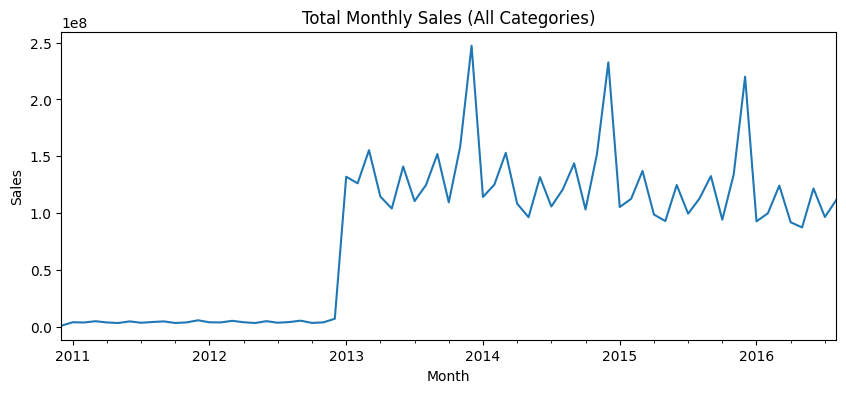

,unique_id,y
5,A|A|M,854842390.0
42,B|C|W,660922180.0
65,C|C|W,649790668.0
11,A|C|ALL,354243738.0
29,A|J|Z,263460272.0
25,A|I|K,259709643.0
53,B|I|K,195120144.0
70,C|G|F,176420725.0
52,B|I|G,133206623.0
13,A|D|ALL,124477709.0


Selected important series (top 2 per Category1):


,Category1,Category2,Category3,unique_id,y
5,A,A,M,A|A|M,257064429.0
65,C,C,W,C|C|W,161339542.0
42,B,C,W,B|C|W,135046917.0
11,A,C,ALL,A|C|ALL,81482297.0
53,B,I,K,B|I|K,53413383.0
70,C,G,F,C|G|F,42898334.0


,unique_id,regime,model,horizon,smape_mean,n_origins_used
2,A|A|M,full,AutoARIMA,1,0.286283,12
5,A|A|M,full,AutoARIMA,3,0.283187,12
8,A|A|M,full,AutoARIMA,6,0.271413,12
11,A|A|M,full,AutoARIMA,12,0.244573,12
1,A|A|M,full,ETS,1,0.223389,12
4,A|A|M,full,ETS,3,0.255663,12
7,A|A|M,full,ETS,6,0.269695,12
10,A|A|M,full,ETS,12,0.263851,12
0,A|A|M,full,SeasonalNaive,1,0.092957,12
3,A|A|M,full,SeasonalNaive,3,0.097370,12



Best model/regime per series (by h=12 sMAPE):


,unique_id,regime,model,horizon,smape_h12,n_origins_used
0,A|A|M,post2013,ETS,12,0.049973,8
1,A|C|ALL,post2013,AutoARIMA,12,0.208403,8
2,B|C|W,post2013,ETS,12,0.141096,8
3,B|I|K,post2013,SeasonalNaive,12,0.124928,8
4,C|C|W,full,SeasonalNaive,12,0.112592,12
5,C|G|F,post2013,ETS,12,0.105111,8



Forecast sample:


,Category1,Category2,Category3,unique_id,ds,yhat,yhat_lower80,yhat_upper80,model,regime
0,A,A,M,A|A|M,2016-09-01,2.507048e+07,2.381041e+07,2.633055e+07,ETS,post2013
1,A,A,M,A|A|M,2016-10-01,1.981876e+07,1.855869e+07,2.107883e+07,ETS,post2013
2,A,A,M,A|A|M,2016-11-01,2.904370e+07,2.778363e+07,3.030378e+07,ETS,post2013
3,A,A,M,A|A|M,2016-12-01,4.400393e+07,4.274385e+07,4.526400e+07,ETS,post2013
4,A,A,M,A|A|M,2017-01-01,2.093731e+07,1.967724e+07,2.219739e+07,ETS,post2013
5,A,A,M,A|A|M,2017-02-01,2.285051e+07,2.159044e+07,2.411059e+07,ETS,post2013
6,A,A,M,A|A|M,2017-03-01,2.625529e+07,2.499522e+07,2.751537e+07,ETS,post2013
7,A,A,M,A|A|M,2017-04-01,2.093030e+07,1.967023e+07,2.219038e+07,ETS,post2013
8,A,A,M,A|A|M,2017-05-01,2.050235e+07,1.924228e+07,2.176242e+07,ETS,post2013
9,A,A,M,A|A|M,2017-06-01,2.523826e+07,2.397819e+07,2.649833e+07,ETS,post2013


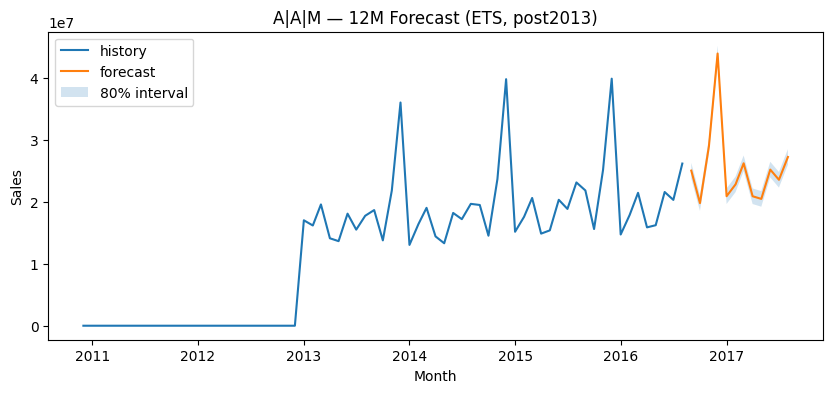

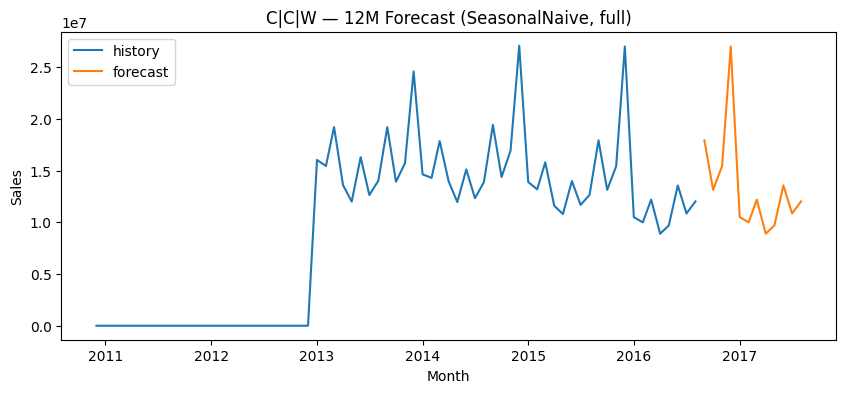

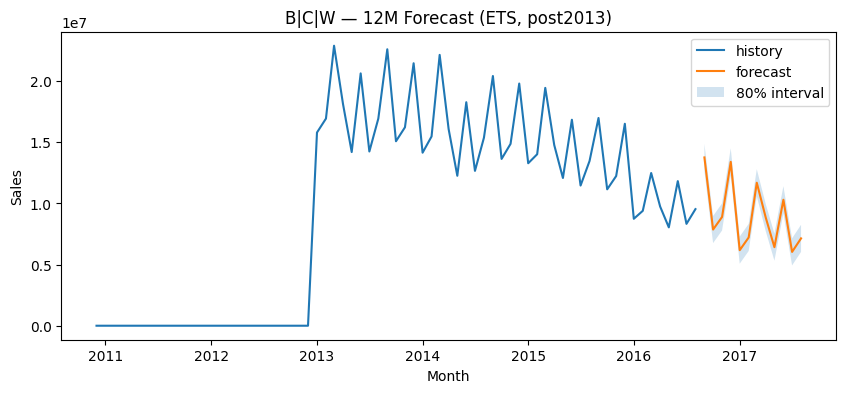

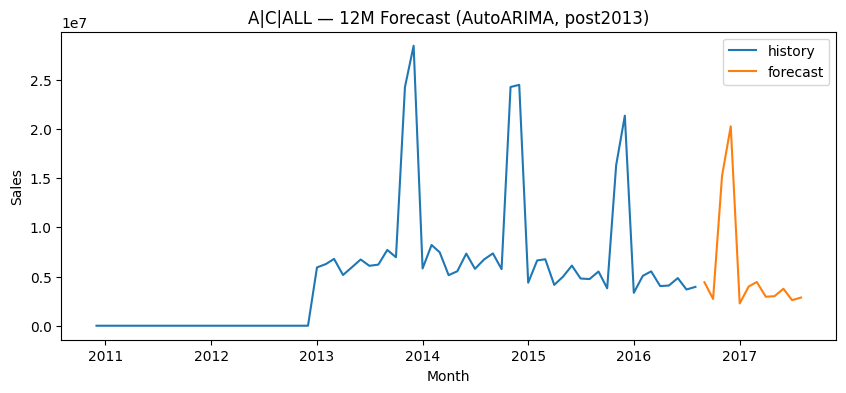

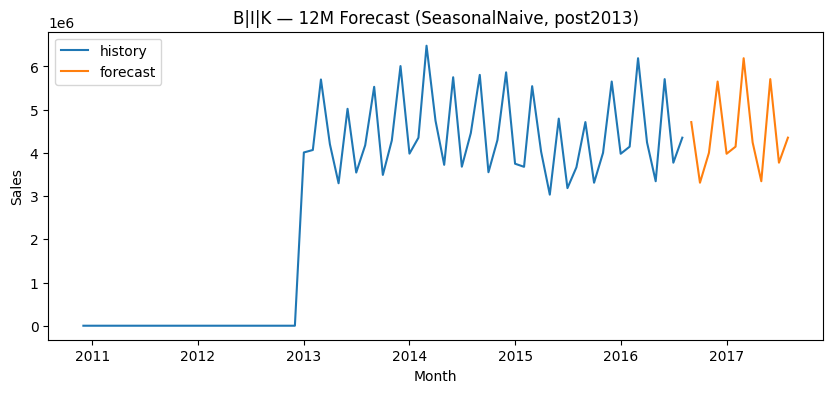

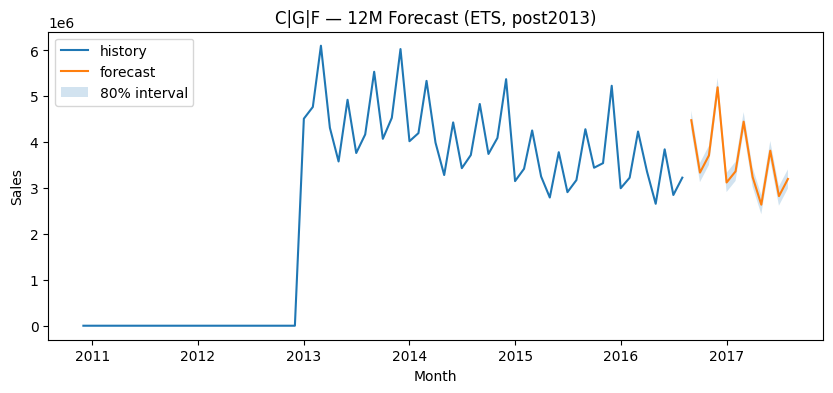


Saved forecast CSV: /content/logitech_forecast_12mo_leveled.csv
Saved model scores CSV: /content/logitech_model_scores_leveled.csv


In [ ]:
# ============================================================
# FULL ONE-BLOCK SOLUTION (Class-Style) — FIXED VERSION
# Level-ups included:
#   1) Seasonal Naive baseline benchmark
#   2) Multi-horizon backtesting (h = 1, 3, 6, 12)
#   3) Post-2013 vs Full-history comparison (structural break handling)
# Outputs:
#   - logitech_forecast_12mo_leveled.csv
#   - logitech_model_scores_leveled.csv
# ============================================================

import re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# StatsForecast (Day 11 style)
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

# ETS (Day 9 style)
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ----------------------------
# 1) Load data
# ----------------------------
DATA_URL = "https://dxl-datasets.s3.us-east-1.amazonaws.com/data/interview_use_case.csv"
df_raw = pd.read_csv(DATA_URL)

# ----------------------------
# 2) Clean + reshape to Nixtla format: [unique_id, ds, y]
# ----------------------------
month_cols = [c for c in df_raw.columns if re.match(r"^\d{2}-[A-Za-z]{3}$", str(c))]

df = df_raw.dropna(subset=["Category1", "Category2"], how="all").copy()
df["Category3"] = df["Category3"].fillna("ALL")

long = df.melt(
    id_vars=["Category1", "Category2", "Category3"],
    value_vars=month_cols,
    var_name="month_str",
    value_name="sales"
)

long["ds"] = pd.to_datetime(long["month_str"], format="%y-%b").dt.to_period("M").dt.to_timestamp()
long["sales"] = pd.to_numeric(long["sales"], errors="coerce").fillna(0.0)
long["y"] = long["sales"].clip(lower=0.0)

long["unique_id"] = (
    long["Category1"].astype(str) + "|" +
    long["Category2"].astype(str) + "|" +
    long["Category3"].astype(str)
)

# Aggregate duplicates to avoid non-unique ds issues
ts = (long.groupby(["unique_id", "ds"], as_index=False)["y"]
          .sum()
          .sort_values(["unique_id", "ds"]))

cats = long[["unique_id", "Category1", "Category2", "Category3"]].drop_duplicates()

print("Tidy TS shape:", ts.shape)
print("Unique series:", ts["unique_id"].nunique())
print("Date range:", ts["ds"].min().date(), "→", ts["ds"].max().date())

# ----------------------------
# 3) EDA quick visuals
# ----------------------------
overall = ts.groupby("ds", as_index=True)["y"].sum().sort_index()
overall.plot(figsize=(10,4), title="Total Monthly Sales (All Categories)")
plt.xlabel("Month"); plt.ylabel("Sales"); plt.show()

series_total = ts.groupby("unique_id", as_index=False)["y"].sum().sort_values("y", ascending=False)
display(series_total.head(10))

# ----------------------------
# 4) Select important categories (top 2 per Category1 by last-12-month sales)
# ----------------------------
max_ds = ts["ds"].max()
start12 = max_ds - pd.DateOffset(months=11)

last12 = ts[(ts["ds"] >= start12) & (ts["ds"] <= max_ds)].merge(cats, on="unique_id", how="left")

imp = (last12.groupby(["Category1", "Category2", "Category3", "unique_id"], as_index=False)["y"]
            .sum()
            .sort_values("y", ascending=False))

top_series = (imp.sort_values("y", ascending=False)
                 .groupby("Category1", as_index=False)
                 .head(2)
                 .sort_values("y", ascending=False))

selected = top_series["unique_id"].tolist()
print("Selected important series (top 2 per Category1):")
display(top_series)

plot_df = ts[ts["unique_id"].isin(selected)].copy()

# ----------------------------
# 5) Utility: sMAPE
# ----------------------------
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred))
    denom = np.where(denom == 0, 1.0, denom)
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom))

# ----------------------------
# 6) Forecast helpers for each model
# ----------------------------
SEASON_LENGTH = 12
BREAK_DATE = pd.Timestamp("2013-01-01")

def seasonal_naive_forecast(train_y: np.ndarray, h: int, season_length: int = 12):
    """Repeat last seasonal cycle; fallback to last value if insufficient history."""
    train_y = np.asarray(train_y, dtype=float)
    if len(train_y) == 0:
        return np.zeros(h, dtype=float)
    if len(train_y) < season_length:
        return np.repeat(train_y[-1], h)
    last_season = train_y[-season_length:]
    reps = int(np.ceil(h / season_length))
    return np.tile(last_season, reps)[:h]

def ets_forecast(train_series: pd.Series, h: int, season_length: int = 12):
    """ETS additive seasonal (fallback to trend-only)."""
    y = train_series.asfreq("MS")
    try:
        model = ExponentialSmoothing(y, trend="add", seasonal="add", seasonal_periods=season_length)\
                .fit(optimized=True, use_brute=True)
    except Exception:
        model = ExponentialSmoothing(y, trend="add").fit(optimized=True)
    return model.forecast(h).values

def autoarima_forecast(train_df: pd.DataFrame, h: int, season_length: int = 12):
    """StatsForecast AutoARIMA forecast."""
    sf = StatsForecast(models=[AutoARIMA(season_length=season_length)], freq="MS", n_jobs=1)
    fc = sf.forecast(df=train_df, h=h)
    return fc["AutoARIMA"].values.astype(float)

# ----------------------------
# 7) Multi-horizon backtesting + post-break comparison
# ----------------------------
HORIZONS = [1, 3, 6, 12]

def backtest_multi_horizon(df_one: pd.DataFrame,
                           horizons=(1,3,6,12),
                           n_origins=12,
                           season_length=12,
                           break_date=pd.Timestamp("2013-01-01")):
    """
    Expanding-window backtest across multiple horizons.
    Evaluates:
      Regimes: full history vs post-break (>= break_date)
      Models: SeasonalNaive, ETS, AutoARIMA
    Returns a tidy DataFrame of mean sMAPE by (regime, model, horizon).
    """
    # Ensure correct sorting and monthly frequency
    df_one = df_one.sort_values("ds").copy()
    df_one["ds"] = pd.to_datetime(df_one["ds"]).dt.to_period("M").dt.to_timestamp()
    df_one = df_one.set_index("ds").asfreq("MS")

    uid = df_one["unique_id"].iloc[0]
    y_all = df_one["y"].values.astype(float)
    T = len(df_one)
    max_h = int(max(horizons))

    # Determine feasible number of origins
    split = T - (n_origins + max_h)
    if split < 24:
        n_origins_eff = max(3, min(n_origins, max(1, T - (24 + max_h))))
    else:
        n_origins_eff = n_origins

    split = T - (n_origins_eff + max_h)
    if split < 12:
        n_origins_eff = max(1, T - (12 + max_h))
        split = T - (n_origins_eff + max_h)

    origin_ends = [split + i for i in range(n_origins_eff) if (split + i + max_h) <= T]

    scores = {}

    def add_score(regime, model, h, val):
        scores.setdefault((regime, model, h), []).append(val)

    # Find first post-break index (FIXED: no .values usage)
    post_mask = (df_one.index >= break_date)
    if np.any(post_mask):
        post_start_idx = int(np.argmax(post_mask))  # first True
    else:
        post_start_idx = T  # no post-break data

    for end_idx in origin_ends:
        train_full = df_one.iloc[:end_idx].copy()
        test_block = df_one.iloc[end_idx:end_idx + max_h].copy()
        if len(test_block) < max_h:
            continue

        # ---------- FULL HISTORY ----------
        y_train_full = train_full["y"].values

        for h in horizons:
            y_true = test_block["y"].values[:h]

            # SeasonalNaive
            y_hat = seasonal_naive_forecast(y_train_full, h, season_length)
            add_score("full", "SeasonalNaive", h, smape(y_true, y_hat))

            # ETS
            try:
                y_hat = ets_forecast(train_full["y"], h, season_length)
                add_score("full", "ETS", h, smape(y_true, y_hat))
            except Exception:
                add_score("full", "ETS", h, np.nan)

            # AutoARIMA
            try:
                train_full_sf = train_full.reset_index()[["unique_id", "ds", "y"]]
                y_hat = autoarima_forecast(train_full_sf, h, season_length)
                add_score("full", "AutoARIMA", h, smape(y_true, y_hat))
            except Exception:
                add_score("full", "AutoARIMA", h, np.nan)

        # ---------- POST-BREAK ----------
        post_train_start = max(post_start_idx, 0)
        if post_train_start < end_idx and (end_idx - post_train_start) >= 24:
            train_post = df_one.iloc[post_train_start:end_idx].copy()
            y_train_post = train_post["y"].values

            for h in horizons:
                y_true = test_block["y"].values[:h]

                # SeasonalNaive
                y_hat = seasonal_naive_forecast(y_train_post, h, season_length)
                add_score("post2013", "SeasonalNaive", h, smape(y_true, y_hat))

                # ETS
                try:
                    y_hat = ets_forecast(train_post["y"], h, season_length)
                    add_score("post2013", "ETS", h, smape(y_true, y_hat))
                except Exception:
                    add_score("post2013", "ETS", h, np.nan)

                # AutoARIMA
                try:
                    train_post_sf = train_post.reset_index()[["unique_id", "ds", "y"]]
                    y_hat = autoarima_forecast(train_post_sf, h, season_length)
                    add_score("post2013", "AutoARIMA", h, smape(y_true, y_hat))
                except Exception:
                    add_score("post2013", "AutoARIMA", h, np.nan)
        else:
            for h in horizons:
                add_score("post2013", "SeasonalNaive", h, np.nan)
                add_score("post2013", "ETS", h, np.nan)
                add_score("post2013", "AutoARIMA", h, np.nan)

    rows = []
    for (regime, model, h), vals in scores.items():
        v = np.asarray(vals, dtype=float)
        rows.append({
            "unique_id": uid,
            "regime": regime,
            "model": model,
            "horizon": int(h),
            "smape_mean": float(np.nanmean(v)) if np.isfinite(v).any() else np.nan,
            "n_origins_used": int(np.sum(np.isfinite(v)))
        })

    return pd.DataFrame(rows)

# ----------------------------
# 8) Run scoring for each selected series
# ----------------------------
score_frames = []
for uid in selected:
    one = plot_df[plot_df["unique_id"] == uid][["unique_id","ds","y"]].copy()
    perf = backtest_multi_horizon(one, horizons=HORIZONS, n_origins=12,
                                  season_length=SEASON_LENGTH, break_date=BREAK_DATE)
    score_frames.append(perf)

scores_df = pd.concat(score_frames, ignore_index=True)
display(scores_df.sort_values(["unique_id","regime","model","horizon"]).head(20))

# Best choice per series based on horizon=12 (lowest mean sMAPE)
best_choices = (scores_df[scores_df["horizon"] == 12]
                .dropna(subset=["smape_mean"])
                .sort_values(["unique_id","smape_mean"])
                .groupby("unique_id", as_index=False)
                .first()
                .rename(columns={"smape_mean":"smape_h12"}))

print("\nBest model/regime per series (by h=12 sMAPE):")
display(best_choices)

# ----------------------------
# 9) Fit best model and forecast 12 months ahead
# ----------------------------
FINAL_H = 12
forecast_rows = []

for uid in selected:
    choice = best_choices[best_choices["unique_id"] == uid].iloc[0]
    best_regime = choice["regime"]
    best_model = choice["model"]

    series_all = plot_df[plot_df["unique_id"] == uid][["unique_id","ds","y"]].copy().sort_values("ds")
    series_all["ds"] = pd.to_datetime(series_all["ds"]).dt.to_period("M").dt.to_timestamp()

    if best_regime == "post2013":
        series_train = series_all[series_all["ds"] >= BREAK_DATE].copy()
        if len(series_train) < 24:  # fallback
            series_train = series_all.copy()
            best_regime = "full_fallback"
    else:
        series_train = series_all.copy()

    last_ds = series_all["ds"].max()
    future_ds = pd.date_range(last_ds + pd.offsets.MonthBegin(1), periods=FINAL_H, freq="MS")

    if best_model == "SeasonalNaive":
        yhat = seasonal_naive_forecast(series_train["y"].values, FINAL_H, SEASON_LENGTH)
        lo = np.full(FINAL_H, np.nan); hi = np.full(FINAL_H, np.nan)

    elif best_model == "ETS":
        y_hist = series_train.set_index("ds")["y"].asfreq("MS")
        try:
            m = ExponentialSmoothing(y_hist, trend="add", seasonal="add", seasonal_periods=SEASON_LENGTH)\
                .fit(optimized=True, use_brute=True)
        except Exception:
            m = ExponentialSmoothing(y_hist, trend="add").fit(optimized=True)

        fc = m.forecast(FINAL_H)
        yhat = fc.values.astype(float)

        resid = (y_hist - m.fittedvalues).dropna()
        sigma = float(resid.std(ddof=1)) if len(resid) > 2 else 0.0
        lo = np.clip(yhat - 1.28*sigma, 0, None)
        hi = np.clip(yhat + 1.28*sigma, 0, None)

    else:  # AutoARIMA
        sf = StatsForecast(models=[AutoARIMA(season_length=SEASON_LENGTH)], freq="MS", n_jobs=1)
        fc = sf.forecast(df=series_train, h=FINAL_H)
        yhat = fc["AutoARIMA"].values.astype(float)
        lo = np.full(FINAL_H, np.nan); hi = np.full(FINAL_H, np.nan)

    c1, c2, c3 = uid.split("|")
    for d, yh, l, u in zip(future_ds, yhat, lo, hi):
        forecast_rows.append({
            "Category1": c1,
            "Category2": c2,
            "Category3": c3,
            "unique_id": uid,
            "ds": d.date().isoformat(),
            "yhat": float(max(yh, 0.0)),
            "yhat_lower80": (float(l) if np.isfinite(l) else np.nan),
            "yhat_upper80": (float(u) if np.isfinite(u) else np.nan),
            "model": best_model,
            "regime": best_regime
        })

forecast_df = pd.DataFrame(forecast_rows).sort_values(["unique_id","ds"])
print("\nForecast sample:")
display(forecast_df.head(12))

# ----------------------------
# 10) Plots: history + forecast for each selected series
# ----------------------------
for uid in selected:
    hist = plot_df[plot_df["unique_id"] == uid].sort_values("ds")
    fc = forecast_df[forecast_df["unique_id"] == uid].copy()
    fc["ds_dt"] = pd.to_datetime(fc["ds"])

    plt.figure(figsize=(10,4))
    plt.plot(hist["ds"], hist["y"], label="history")
    plt.plot(fc["ds_dt"], fc["yhat"], label="forecast")

    if fc["yhat_lower80"].notna().any():
        plt.fill_between(fc["ds_dt"], fc["yhat_lower80"], fc["yhat_upper80"], alpha=0.2, label="80% interval")

    mdl = fc["model"].iloc[0]
    reg = fc["regime"].iloc[0]
    plt.title(f"{uid} — 12M Forecast ({mdl}, {reg})")
    plt.xlabel("Month"); plt.ylabel("Sales"); plt.legend(); plt.show()

# ----------------------------
# 11) Export deliverables (CSV)
# ----------------------------
out_forecast = Path("logitech_forecast_12mo_leveled.csv")
out_scores = Path("logitech_model_scores_leveled.csv")

forecast_df.to_csv(out_forecast, index=False)
scores_df.to_csv(out_scores, index=False)

print("\nSaved forecast CSV:", out_forecast.resolve())
print("Saved model scores CSV:", out_scores.resolve())

The dataset contains 78 unique product-category time series spanning December 2010 through August 2016, totaling 5,382 monthly observations after cleaning and aggregation. The data was reshaped into a tidy time-series format (unique_id, ds, y) and negative sales were clipped to zero to address potential return adjustments.

A significant structural break occurs in January 2013, where total monthly sales increase from an average of approximately $4M pre-2013 to $126M post-2013, representing a ~2,800% level shift. This magnitude strongly suggests a reporting, channel, or portfolio inclusion change rather than organic growth. As a result, model performance was evaluated under both full-history and post-2013-only regimes.

Sales exhibit clear and stable annual seasonality, with Q4 (Oct–Dec) consistently representing peak demand. December is the strongest month across most high-volume series. Seasonal uplift is meaningful and repeatable, justifying the use of seasonal forecasting models with a 12-month season length.

Revenue is concentrated among a small subset of product-category combinations. For business relevance, forecasting focused on the top two revenue-generating series per Category1 group, based on trailing 12-month sales.

Multi-horizon backtesting (h = 1, 3, 6, 12 months) was conducted using an expanding-window approach. Across most selected series, post-2013 modeling outperformed full-history modeling, confirming that the structural break materially affects forecast accuracy. In several cases, simple Seasonal Naive or ETS models performed competitively or better than AutoARIMA, indicating that the demand pattern is stable and primarily driven by seasonal structure rather than complex dynamics.

Final 12-month forecasts project continuation of post-2013 demand levels with recurring seasonal peaks and no strong acceleration or decline trend detected.